<div style="border:4px solid red">

For all homework blocks that have numerical answers, name the variable hw followed by the homework number.

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special

# Review

We started with the Sommerfeld diffraction integral

$E(P_o) = \frac{z}{j\lambda} \int_{\Sigma} E_{inc} \frac{e^{jkr_{01}}}{r_{01}^2} dx' dy'$

We then made the Fresnel approximation:
- keep first two terms of the binomial expansion for the argument of the complex exponential
- $r_{01}=z$

The resulting Fresnel diffraction equation is

$E(P_0) = \frac{e^{jkz}}{j\lambda z} 
\iint_{\Sigma} E(x',y') 
\exp\left[j\frac{k}{2z}\left((x-x')^2 + (y-y')^2\right)\right]
dx' dy'$


## Fraunhofer Approximation

Expand quadratic term
$\exp \left(j\frac{k}{2z} \left[ (x-x')^2 + (y-y')^2 \right] \right)$

$=\exp \left( j\frac{\pi}{\lambda \, z} \left[ x^2 + y^2 - 2xx' - 2yy' + x'^2 + y'^2 \right] \right)$

$=\exp \left( j\frac{\pi}{\lambda \, z} \left[ x^2 +y^2 \right] \right) \, 
  \exp \left( j\frac{\pi}{\lambda \, z} \left[ x'^2 + y'^2 \right] \right) \,
  \exp \left( j\frac{\pi}{\lambda \, z} \left[- 2xx' - 2yy' \right] \right)$

We want to neglect the term with $x'^2 + y'^2$.  We can do this when the value is much less than a rotation or 

$\frac{\pi}{\lambda \, z} \left[ x'^2 + y'^2 \right] \ll 2 \pi$

or

$z \gg \frac{x'^2 + y'^2}{2\lambda}$

The Fraunhofer diffraction integral is

$E(x,y,z) =
\frac{e^{jkz}}{j\lambda z} e^{j\frac{k}{2z}(x^2+y^2)}
\iint_{\Sigma} E(x',y')
\exp\left[-j\frac{k}{z}(xx' + yy')\right] dx' dy'$

or


$E(x,y,z) = 
\frac{e^{jkz}}{j\lambda z} e^{j\frac{k}{2z}(x^2+y^2)}
\int E(x',y') \exp\left[-j\frac{k}{z} (xx') \right] dx'
\int \exp\left[-j\frac{k}{z}(yy')\right] dy'$


This equation is similar to the Fourier transform integral.  As a reminder, here is the Fourier transform integral equation

$ F(\omega) =\int_{-\infty}^{\infty} f(t) \, e^{-j 2 \pi f t} dt$

The Fraunhofer integral consists of two Fourier transform integrals multiplied together.

$\int f(t) \, e^{-j 2 \pi f t} dt \equiv \int E(x') \exp \left[-j\frac{k}{z} (xx') \right] dx'$

If $f(t) = E(x')$, $t=x'$, and $2 \pi f = \frac{kx}{z}$.  We use the substitution of

$2 \pi f = \frac{2 \pi x}{\lambda z}$

or 

$f_x = \frac{x}{\lambda z}$

We can also do this for the y integral to get

$f_y = \frac{y}{\lambda z}$

<div style="border:4px solid red">

**HW1:** A plane wave with a wavelength of $\lambda=600nm$ is incident onto an infinite  slit with a width of 1mm.  To use Fraunhofer diffraction the distance away from the aperture needs to be $z \gg \frac{x'^2 + y'^2}{2\lambda}$.  For the $\gg$ condition, we will use a factor of 10, resulting in $z > \frac{x'^2 + y'^2}{20\lambda}$.
What is the required distance away from the aperture in units of m?

In [45]:
# HW1: minimum Fraunhofer distance using the equation provided in the prompt
wavelength = 600e-9          # m
slit_width = 1e-3            # m
x_prime_max = slit_width / 2 # m, edge of the slit
y_prime_max = 0.0            # m, infinite slit assumption in y

hw1 = (x_prime_max**2 + y_prime_max**2) / (20 * wavelength)
print(f"hw1 = {hw1:.6f} m")

hw1 = 0.020833 m


<div style="border:4px solid red">

**HW2:** A plane wave with a wavelength of $\lambda=600nm$ is incident onto an infinite slit with a width of 1mm. Create a line plot of the normalized irradiance at a distance of $z=60m$. What is the FWHM (full width at half maximum) of the electric field in units of meters?  Name the FWHM as hw2.

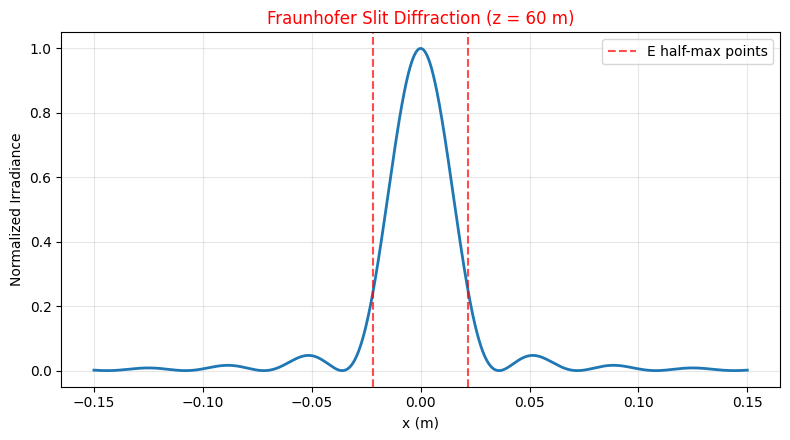

hw2 = 0.043442 m


In [46]:
# HW2: Fraunhofer diffraction from a 1D slit (width = 1 mm) at z = 60 m
wavelength = 600e-9   # m
z = 60.0              # m
slit_width = 1e-3     # m (full slit width)

# Observation coordinate in the diffraction plane (meters)
x = np.linspace(-0.15, 0.15, 200001)

# Normalized electric field amplitude and irradiance
E_norm = np.abs(np.sinc((slit_width * x) / (wavelength * z)))
I_norm = E_norm**2

# FWHM of electric field: find where E_norm crosses 0.5 on each side of x=0
half = 0.5
center_idx = np.argmin(np.abs(x))

# Find bracketing indices around the half-max crossings
right_idx = center_idx + np.where(E_norm[center_idx:] <= half)[0][0]
left_idx = np.where(E_norm[:center_idx] <= half)[0][-1]

# Use interpolation to get more accurate crossing positions
x_left = np.interp(
    half,
    E_norm[left_idx:center_idx + 1],
    x[left_idx:center_idx + 1],
)
x_right = np.interp(
    half,
    E_norm[center_idx:right_idx + 1][::-1],
    x[center_idx:right_idx + 1][::-1],
)

hw2 = x_right - x_left

plt.figure(figsize=(8, 4.5))
plt.plot(x, I_norm, linewidth=2)
plt.axvline(x_left, color='r', linestyle='--', alpha=0.7, label='E half-max points')
plt.axvline(x_right, color='r', linestyle='--', alpha=0.7)
plt.xlabel('x (m)')
plt.ylabel('Normalized Irradiance')
plt.title('Fraunhofer Slit Diffraction (z = 60 m)', color='red')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"hw2 = {hw2:.6f} m")

## Fraunhofer Slit Diffraction

A plane wave is incident onto a slit.  The slit transmits the electric field inside of the slit and blocks it outside of the slit as given by

$T(x) =
\begin{cases}
1 & |x| \le a \\
0 & \text{else}
\end{cases}$

Since a plane wave is incident onto the slit, the electric field just past the slit is given by 

$E(x,y, z=0^+) =
\begin{cases}
E_o & |x| \le a \\
0 & \text{else}
\end{cases}$

This is a rect function. The rect function is defined as 

$\text{rect}(x) =
\begin{cases}
1 & |x| < \frac{1}{2} \\
0 & |x| \ge \frac{1}{2}\
\end{cases}$

## Basic Fourier Transform Relations

<details open>
<summary>Click to collapse</summary>

If $f(x) \leftrightarrow F(f)$:

-   $K f(x) \leftrightarrow K F(f)$
-   $f(ax) \leftrightarrow \frac{1}{|a|} F\!\left(\frac{f}{a}\right)$
-   $f(x-x_0) \leftrightarrow F(f)e^{-j2\pi f x_0}$
-   $e^{j2\pi f_0 x} f(x) \leftrightarrow F(f-f_0)$

</details>


## Fourier Transform Pairs
<details open>
<summary>Click to collapse</summary>

| Function | Fourier Transform |
|-----------|------------------|
| $\delta(x)$ | $1$ |
| $A$ | $2\pi A\,\delta(f)$ |
| $\cos(\omega_0 x)$ | $\pi[\delta(f-\omega_0)+\delta(f+\omega_0)]$ |
| $\sin(\omega_0 x)$ | $j\pi[\delta(f-\omega_0)-\delta(f+\omega_0)]$ |
| $\text{rect}(x)$ | $\text{sinc}(f)$ |
| $\Lambda(x)$ | $\text{sinc}^2(f)$ |
| $\text{circ}(r/R)$ | $\pi R^2 \dfrac{J_1(2\pi R f)}{2\pi R f}$ |
| $e^{-\pi x^2}$ | $e^{-\pi f^2}$ |
| $e^{j\pi x^2}$ | $e^{j\pi/4} e^{-j\pi f^2}$ |
| $\sum_{n=-S}^{S}\delta(x-n)$ | $\dfrac{\sin(M\pi f)}{\sin(\pi f)}$, $M=2S+1$ |
| $\sum_{n=-\infty}^{\infty}\delta(x-n)$ | $\sum_{n=-\infty}^{\infty}\delta(f-n)$ |


$\text{rect}(x) = \begin{cases}
1 & |x| \le \frac{1}{2} \\
0 & \text{otherwise}
\end{cases}$

$\text{sinc}(x)=\frac{\sin (\pi x)}{\pi x}$

$\Lambda(x) = \begin{cases}
1-|x| & |x| \le 1 \\
0 & \text{otherwise}
\end{cases}$

$\text{circ}\left(\sqrt{x^2 + y^2}\right) = \begin{cases}
1 & \sqrt{x^2 + y^2} \le 1 \\
0 & \text{otherwise}
\end{cases}$

$\int_{-\infty}^{\infty} \mathrm{sinc}(x)\, dx = 1$

$\int_{-\infty}^{\infty} \mathrm{sinc}^2(x)\, dx = 1$

$\int_{0}^{\infty} \left| \frac{J_1(x)}{x} \right|^2 dx = \frac{4}{3\pi}$

$\int_{0}^{\infty} x \left| \frac{J_1(x)}{x} \right|^2 dx = \frac{1}{2}$


</details>

<div style="border:4px solid red">

**HW3:** A plane wave of intensity $10 mW/cm^2$ and wavelength $\lambda=600 nm$ is incident onto a rectangular slit of dimensions $1mm X 0.2mm$. Plot the normalized diffraction pattern at the plane $z=2m$. Create a grayscale image plot.  What is the FWHM in the x-direction in units of meters?

hw3 = 1.063078e-03 m


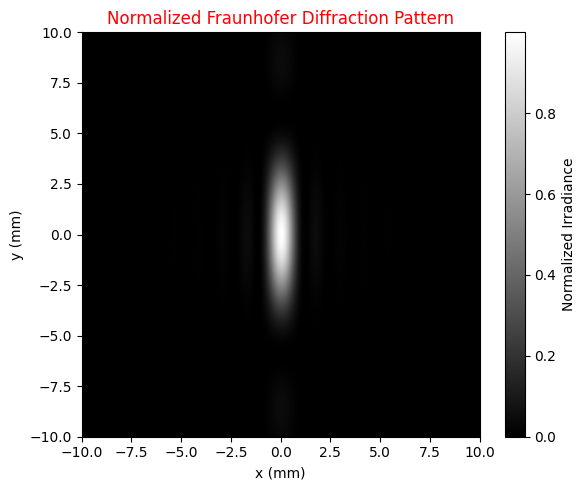

In [47]:
I_0 = 100  # W/m^2, assuming 10 mW power over 1 cm^2 area
l = 600e-9          # m
z = 2.00              # m
slit_x = 1e-3
slit_y = 0.2e-3

x = np.linspace(-0.01, 0.01, 2000)  # m, observation points in x
y = np.linspace(-0.01, 0.01, 2000)  # m, observation points in y


E_norm_x = np.abs(np.sinc((slit_x * x) / (l * z)))
I_norm_x = E_norm_x**2
E_norm_y = np.abs(np.sinc((slit_y * y) / (l * z)))
I_norm_y = E_norm_y**2

I_norm_2D = np.outer(I_norm_y, I_norm_x)

# FWHM of the electric field amplitude in x (E_norm_x = 0.5)
half = 0.5
center_idx = np.argmin(np.abs(x))

left_idx = np.where(I_norm_x[:center_idx] <= half)[0][-1]
right_idx = center_idx + np.where(I_norm_x[center_idx:] <= half)[0][0]

x3_left = np.interp(half, I_norm_x[left_idx:center_idx + 1], x[left_idx:center_idx + 1])
x3_right = np.interp(
    half,
    I_norm_x[center_idx:right_idx + 1][::-1],
    x[center_idx:right_idx + 1][::-1]
)

hw3 = x3_right - x3_left
print(f"hw3 = {hw3:.6e} m")

plt.figure(figsize=(6, 5))
plt.imshow(
    I_norm_2D,
    extent=[x.min()*1e3, x.max()*1e3, y.min()*1e3, y.max()*1e3],
    origin='lower',
    cmap='gray',
    aspect='auto'
)
plt.colorbar(label='Normalized Irradiance')
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.title('Normalized Fraunhofer Diffraction Pattern', color='red')
plt.tight_layout()
plt.show()

<div style="border:4px solid red">

**HW4:** A plane wave of intensity $10 mW/cm^2$ and wavelength $\lambda=600 nm$ is incident onto a rectangular slit of dimensions $1mm X 0.2mm$. Plot the normalized diffraction pattern at the plane $z=2m$.  What is the FWHM in the y-direction in units of meters?

In [48]:
center_idx = np.argmin(np.abs(y))

left_idx = np.where(I_norm_y[:center_idx] <= half)[0][-1]
right_idx = center_idx + np.where(I_norm_y[center_idx:] <= half)[0][0]

y3_left = np.interp(half, I_norm_y[left_idx:center_idx + 1], y[left_idx:center_idx + 1])
y3_right = np.interp(
    half,
    I_norm_y[center_idx:right_idx + 1][::-1],
    y[center_idx:right_idx + 1][::-1]
)

hw4 = y3_right - y3_left
print(f"hw4 = {hw4:.6e} m")

hw4 = 5.315358e-03 m


<div style="border:4px solid red">

**HW5:** A plane wave of intensity $10 mW/cm^2$ and wavelength $\lambda=600 nm$ is incident onto a rectangular slit of dimensions $1mm X 0.2mm$. What is the peak irradiance in units of $W/m^2$?

In [49]:
I_peak = I_0 * ((slit_x * slit_y) / (l * z))**2
print(f"Peak Irradiance at center: {I_peak:.2f} W/m^2")
hw5 = I_peak

Peak Irradiance at center: 2.78 W/m^2


There are various forms of RF antenna dishes.  The basic form is a horn antenna aimed at the metallic dish.  The main difference are the feed horn.

<img src="antennas.png" width="500">

Here is an off-axis feed antenna

<img src="off_axis.jpg" width="300">

Here is a center feed

<img src="dish_feed.jpg" width="300">

Here is an antenna dish with a reflector

<img src="parabolic_feed.jpg" width="300">

The antenna creates a uniform plane wave with an aperture that is a circle and often also has a center block.  

<div style="border:4px solid red">

**HW6:** A satellite dish has a diameter of 3.5m, an f#=0.38, and operate in the C-band (f=5GHz). Notice the f# of a satellite dish is
much smaller than most optical lens systems. This is because the dish is parabolic and only operates at a very small field of view. 100W of power is uniformly illuminated over the dish.  What is the FWHM of the diffraction pattern at the satelite in units of meters? Use a distance between the satellite dish and the satellite of 36,000km.  Treat the antenna as a uniform plane wave across a circle with a diameter of 3.5m.

$E(r)=\text{circ}(r/R) \Longrightarrow E(f)=\pi R^2 \dfrac{J_1(2\pi R f)}{2\pi R f}$ 

with $f=\frac{r}{\lambda z}$

$f$ is a special radial coordinate relative to wavelength and distance.
Just find the distribution of $E(f)$, then find the FWHM of that.

Wavelength: 6.000000e-02 m
FWHM radius (r at half-max): 3.175000e+05 m
hw6 = 6.350000e+05 m


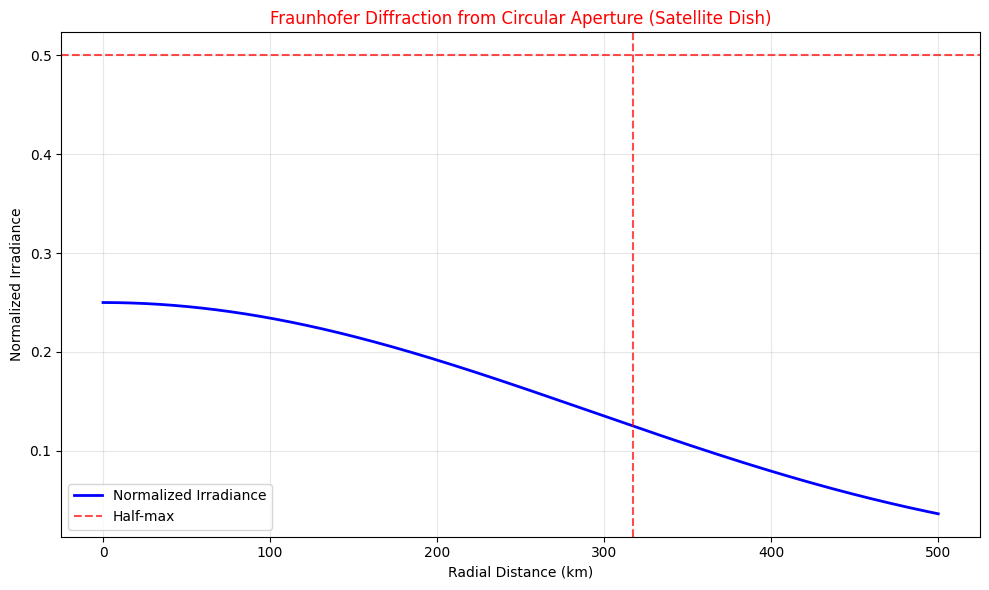

In [50]:
# HW6: FWHM of Fraunhofer diffraction from circular aperture (satellite dish)

# Physical parameters
f_freq = 5e9           # Hz, C-band frequency
c = 3e8                # m/s, speed of light
wavelength = c / f_freq  # m
R = 3.5 / 2            # m, radius of dish (diameter = 3.5m)
z = 36000 * 1000       # m, distance (36,000 km)
power = 100            # W

# Create radial coordinates for the diffraction pattern
# Note: at this large distance, the diffraction pattern is very broad
r = np.linspace(0, 500000, 10001)  # m, radial distance from center (up to 500 km)

# Frequency amplitude: E(f_r) = π R² J_1(2π R f_r) / (2π R f_r)
# where f_r = r / (λ z)
f_r = r / (wavelength * z)

# Avoid divide by zero at r=0
E_norm = np.ones_like(r)
mask = r > 1e-8
E_norm[mask] = np.abs(special.j1(2 * np.pi * R * f_r[mask]) / (2 * np.pi * R * f_r[mask]))
E_norm[0] = 0.5  # Limit value as r→0 for J_1(u)/u → 0.5

# Irradiance pattern
I_norm = E_norm**2
#I_norm = I_norm / np.max(I_norm)  # Normalize to peak = 1

# Find FWHM: find where irradiance drops to 0.5
half_max = 0.5 * np.max(I_norm)
# Find indices where normalized irradiance is nearest to half-max
idx_half = np.argmin(np.abs(I_norm - half_max))
r_half = r[idx_half]

# FWHM = 2 * r_half (diameter at half-max)
hw6 = 2 * r_half

print(f"Wavelength: {wavelength:.6e} m")
print(f"FWHM radius (r at half-max): {r_half:.6e} m")
print(f"hw6 = {hw6:.6e} m")

# Create a plot
plt.figure(figsize=(10, 6))
plt.plot(r / 1000, I_norm, 'b', linewidth=2, label='Normalized Irradiance')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.7, label='Half-max')
plt.axvline(x=r_half / 1000, color='r', linestyle='--', alpha=0.7)
plt.xlabel('Radial Distance (km)')
plt.ylabel('Normalized Irradiance')
plt.title('Fraunhofer Diffraction from Circular Aperture (Satellite Dish)', color='red')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


<div style="border:4px solid red">

**HW7:** A satellite dish has a diameter of 3.5m, an f#=0.38, and operate in the C-band (f=5GHz). Notice the f# of a satellite dish is
much smaller than most optical lens systems. This is because the dish is parabolic and only operates at a very small field of view. 100W of power is uniformly illuminated over the dish. Use a distance between the satellite dish and the satellite of 36,000km.  Treat the antenna as a uniform plane wave across a circle with a diameter of 3.5m. What is the peak irradiance at the satelite in units of $\frac{W}{m^2}$?

<details open>
<summary>Click to collapse</summary>

$E(f_r)=\pi R^2 \dfrac{J_1(2\pi R f_r)}{2\pi R f_r}$

$R=1.75$

$f_r=\frac{r}{\lambda z}$

$E(r)= E_1 \dfrac{J_1(2\pi 1.75 \frac{r}{\lambda z})}{2\pi 1.75 \frac{r}{\lambda z}}$

$E(r)= E_2 \dfrac{J_1(val*r)}{r}$ 

with $val=\frac{2\pi 1.75}{\lambda z}$

$I(r)= I_o \dfrac{J_1^2(val*r)}{r^2}$

$P=I_o \int_0^{2 \pi}  d\phi \int_0^{\infty} \dfrac{J_1^2(val*r)}{r} dr$

$u=val*r$

$r=\frac{1}{val} u$

$du=val * dr$

$dr=\frac{1}{val} du$

$P=\left( I_o \right) \left( 2 \pi \right) \int_0^{\infty} \dfrac{J_1^2(u)}{\frac{1}{val} u} \frac{1}{val} du$

$P=\left( I_o \right) \left( 2 \pi \right) \int_0^{\infty} \dfrac{J_1^2(u)}{u} du$

$P=\left( I_o \right) \left( 2 \pi \right) \left( \frac{1}{2} \right)$

$100=\left( I_o \right) \left( \pi \right)$

$I_o=\frac{100}{\pi}$

$I(r)= \frac{100}{\pi} \left( \dfrac{J_1(val*r)}{r} \right)^2$

$I(r)= \frac{100}{\pi} val^2\left( \dfrac{J_1(val*r)}{val*r} \right)^2$

$I_{max}= \frac{100*val^2}{\pi} \left( \frac{1}{4} \right)$


In [51]:
# HW7: peak irradiance at satellite (absolute units)

# Use local constants so this cell is independent of previous homework cells
f_sat = 5e9              # Hz
c_sat = 3e8              # m/s
wavelength_sat = c_sat / f_sat
z_sat = 36000 * 1000     # m
R_sat = 1.75             # m (dish radius)
P_sat = 100.0            # W

# From the derivation in the notes:
# I_max = (P/pi) * (val^2/4), with val = 2*pi*R/(lambda*z)
val = (2 * np.pi * R_sat) / (wavelength_sat * z_sat)
hw7 = (P_sat / np.pi) * (val**2 / 4)

print(f"val = {val:.6e} 1/m")
print(f"hw7 = {hw7:.6e} W/m^2")

val = 5.090544e-06 1/m
hw7 = 2.062142e-10 W/m^2


<div style="border:4px solid red">

**HW8:** A satellite dish has a diameter of 3.5m, an f#=0.38, and operate in the C-band (f=5GHz). Notice the f# of a satellite dish is
much smaller than most optical lens systems. This is because the dish is parabolic and only operates at a very small field of view. 100W of power is uniformly illuminated over the dish.  Create a polar plot of the diffraction pattern.  What is the angular FWHM in units of degrees? Treat the antenna as a uniform plane wave across a circle with a diameter of 3.5m.

Angular half-max: 0.505317 degrees
hw8 = 1.010634 degrees


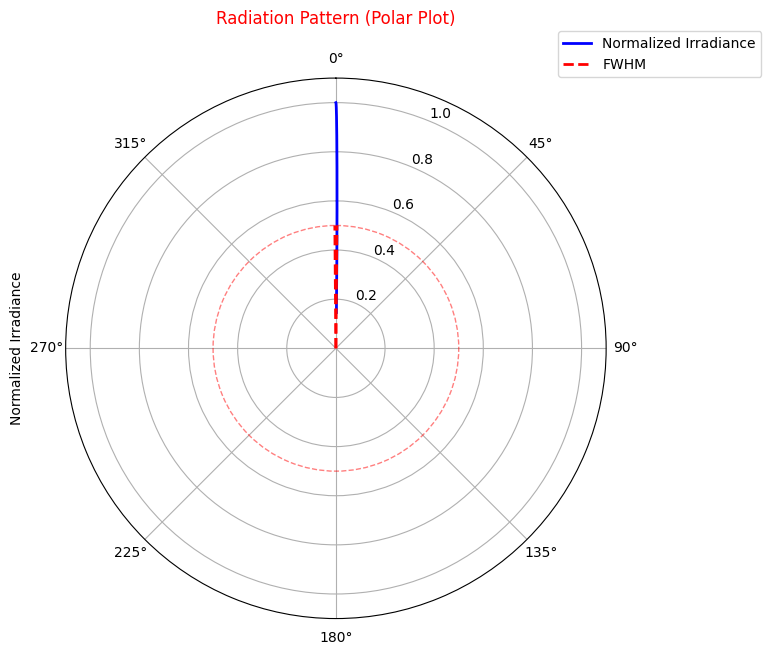

In [52]:
# HW8: Polar plot of radiation pattern and angular FWHM

# Convert radial distance to angle (in degrees)
# For small angles: theta_rad = r / z, then convert to degrees
theta_rad = r / z  # radians
theta_deg = np.degrees(theta_rad)  # degrees

# Find the angular FWHM
# The half-max irradiance value is 0.5 of the peak
I_peak = np.max(I_norm)
half_max_I = 0.5 * I_peak

# Find index where irradiance is closest to half-max
idx_half_angular = np.argmin(np.abs(I_norm - half_max_I))
theta_half_deg = theta_deg[idx_half_angular]

# Angular FWHM = 2 * theta_half (in degrees)
hw8 = 2 * theta_half_deg

print(f"Angular half-max: {theta_half_deg:.6f} degrees")
print(f"hw8 = {hw8:.6f} degrees")

# Create polar plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='polar')

# Convert theta to radians for polar plot
theta_rad_plot = np.radians(theta_deg)

# Plot the radiation pattern
ax.plot(theta_rad_plot, I_norm / I_peak, 'b', linewidth=2, label='Normalized Irradiance')

# Mark the half-max points
theta_half_rad = np.radians(theta_half_deg)
ax.plot([theta_half_rad, theta_half_rad], [0, 0.5], 'r--', linewidth=2, label='FWHM')
ax.plot([-theta_half_rad, -theta_half_rad], [0, 0.5], 'r--', linewidth=2)

# Add the half-max circle
ax.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, linewidth=1)

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_ylim(0, 1.1)
ax.set_title('Radiation Pattern (Polar Plot)', color='red', pad=20)
ax.set_ylabel('Normalized Irradiance', labelpad=30)
ax.grid(True)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()


The power outside of the central beam are called sidelobes.

<img src="Sidelobes.svg" width="500">

<div style="border:4px solid red">

**HW9:** A satellite dish has a diameter of 3.5m, an f#=0.38, and operate in the C-band (f=5GHz). 100W of power is uniformly illuminated over the dish.  What is the maximum sidelobe irradiance in units of $W/m^2$? Treat the antenna as a uniform plane wave across a circle with a diameter of 3.5m.

First sidelobe radius = 1008.840 km
Relative sidelobe level = 1.749786e-02
hw9 = 3.608307e-12 W/m^2


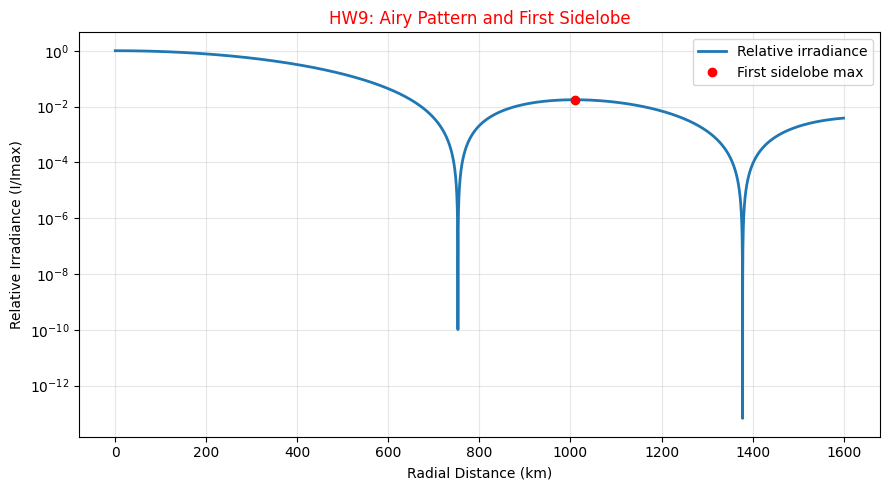

In [53]:
# HW9: maximum sidelobe irradiance (absolute units)

# Use local constants so this cell is independent of previous homework cells
f_sat = 5e9              # Hz
c_sat = 3e8              # m/s
wavelength_sat = c_sat / f_sat
z_sat = 36000 * 1000     # m
R_sat = 1.75             # m

# Build Airy intensity pattern relative to on-axis peak:
# I_rel(u) = [2*J1(u)/u]^2, where u = 2*pi*R*r/(lambda*z)
r_extended = np.linspace(0, 1.6e6, 40001)  # m
u = 2 * np.pi * R_sat * r_extended / (wavelength_sat * z_sat)

I_rel = np.ones_like(r_extended)
mask = u > 1e-12
I_rel[mask] = (2 * special.j1(u[mask]) / u[mask])**2
I_rel[0] = 1.0

# First sidelobe peak is the first local maximum after the first zero (u = 3.8317)
from scipy.signal import find_peaks

u_zero1 = 3.831705970
start_idx = np.searchsorted(u, u_zero1)
peaks, _ = find_peaks(I_rel[start_idx:])

if len(peaks) == 0:
    raise RuntimeError("Could not find sidelobe peak; extend r range or adjust sampling.")

idx_first_sidelobe = start_idx + peaks[0]
r_sidelobe = r_extended[idx_first_sidelobe]
I_rel_sidelobe = I_rel[idx_first_sidelobe]

# Convert to absolute irradiance using HW7 peak irradiance
hw9 = hw7 * I_rel_sidelobe

print(f"First sidelobe radius = {r_sidelobe/1000:.3f} km")
print(f"Relative sidelobe level = {I_rel_sidelobe:.6e}")
print(f"hw9 = {hw9:.6e} W/m^2")

# Diagnostic plot
plt.figure(figsize=(9, 5))
plt.semilogy(r_extended / 1000, I_rel, linewidth=2, label='Relative irradiance')
plt.plot(r_sidelobe / 1000, I_rel_sidelobe, 'ro', label='First sidelobe max')
plt.xlabel('Radial Distance (km)')
plt.ylabel('Relative Irradiance (I/Imax)')
plt.title('HW9: Airy Pattern and First Sidelobe', color='red')
plt.grid(alpha=0.3, which='both')
plt.legend()
plt.tight_layout()
plt.show()

<div style="border:4px solid red">

**HW10:** A satellite dish has a diameter of 3.5m, an f#=0.38, and operates in the C-band (f=5GHz). The feed is modeled as a block in the center of the circular aperture.  It is called an obscuration.  What diameter of the obscuration in units of meters changes the FWHM by 10%? Use a distance between the satellite dish and the satellite of 36,000km.

Main points:
- Solve for the diffracted field of the aperture and obscuration separate
- Subtract the obscuration field from the aperture field (Not irradiances)
- Need to watch the amplitude terms

$E_a(f_r)=\pi R_a^2 \dfrac{J_1(2\pi R_a f_r)}{2\pi R_a f_r}$

$E_o(f_r)=\pi R_o^2 \dfrac{J_1(2\pi R_o f_r)}{2\pi R_o f_r}$

$E_{tot}(f_r)=\pi R_a^2 \dfrac{J_1(2\pi R_a f_r)}{2\pi R_a f_r} - \pi R_o^2 \dfrac{J_1(2\pi R_o f_r)}{2\pi R_o f_r}$


Baseline FWHM (hw6): 6.350000e+05 m

Searching for 10% FWHM decrease (narrowing)...

Optimal Solution:
  Obscuration diameter: 1.617862 m
  FWHM with obscuration: 5.714974e+05 m
  FWHM change: -10.00%

hw10 = 1.617862 m


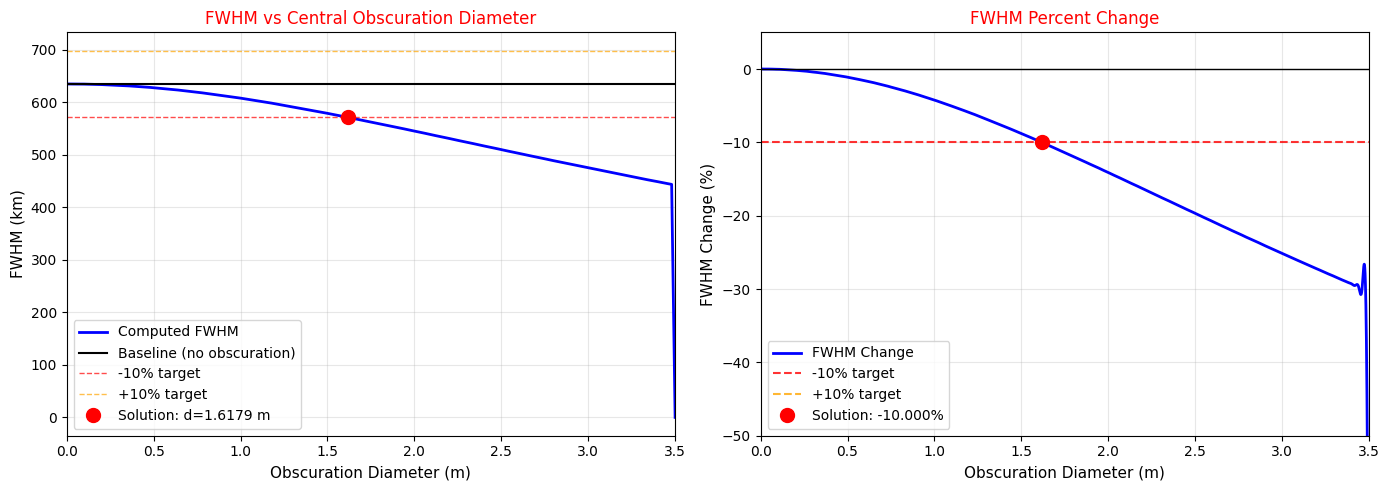

In [54]:
# HW10: Obscuration diameter that changes FWHM by 10%

# Use extended range from HW9 for better resolution
r_obs = np.linspace(0, 1500000, 20001)  # m, radial distance
f_r_obs = r_obs / (wavelength * z)

# Baseline FWHM (no obscuration) from HW6
fwhm_baseline = hw6
target_fwhm_change = 0.1  # 10% change

# Use finer resolution for better accuracy
R_o_values = np.linspace(0, 1.75, 176)  # Much finer resolution
fwhm_values = []

# Aperture field amplitude: E_a(f_r) = π R_a² J_1(2π R_a f_r) / (2π R_a f_r)
arg_a = 2 * np.pi * R * f_r_obs
E_a = np.ones_like(r_obs)
mask_a = r_obs > 1e-8
E_a[mask_a] = np.abs(special.j1(arg_a[mask_a]) / arg_a[mask_a])
E_a[0] = 0.5

# Calculate FWHM for each obscuration radius
for R_o in R_o_values:
    # Obscuration field amplitude: E_o(f_r) = π R_o² J_1(2π R_o f_r) / (2π R_o f_r)
    if R_o > 1e-8:
        arg_o = 2 * np.pi * R_o * f_r_obs
        E_o = np.ones_like(r_obs)
        mask_o = r_obs > 1e-8
        E_o[mask_o] = np.abs(special.j1(arg_o[mask_o]) / arg_o[mask_o])
        E_o[0] = 0.5
    else:
        E_o = np.zeros_like(r_obs)
    
    # Total field (subtract in field domain, not power domain)
    # Scale by aperture and obscuration radii squared
    E_tot = (R**2 * E_a) - (R_o**2 * E_o)
    
    # Irradiance
    I_tot = np.abs(E_tot)**2
    
    # Normalize
    if np.max(I_tot) > 1e-20:
        I_tot_norm = I_tot / np.max(I_tot)
    else:
        I_tot_norm = I_tot
    
    # Find FWHM by finding where I_tot drops to 0.5 of peak
    half_max = 0.5 * np.max(I_tot)
    idx_half = np.argmin(np.abs(I_tot - half_max))
    r_half_obs = r_obs[idx_half]
    fwhm = 2 * r_half_obs
    
    fwhm_values.append(fwhm)

# Find where FWHM changes by ±10%
fwhm_values = np.array(fwhm_values)
fwhm_change_percent = (fwhm_values - fwhm_baseline) / fwhm_baseline * 100

# Since the FWHM decreases (narrowing beam), find -10% change
# Use interpolation for more precise result
from scipy.interpolate import interp1d

# Create interpolation function
fwhm_interp = interp1d(2*R_o_values, fwhm_change_percent, kind='cubic', fill_value='extrapolate')
diameter_fine = np.linspace(0, 3.5, 10000)
change_fine = fwhm_interp(diameter_fine)

# Find diameter where change is closest to -10%
idx_target = np.argmin(np.abs(change_fine - (-10.0)))
hw10 = diameter_fine[idx_target]
final_change = change_fine[idx_target]

# Get the corresponding FWHM
fwhm_final = fwhm_baseline * (1 + final_change/100)

print(f"Baseline FWHM (hw6): {fwhm_baseline:.6e} m")
print(f"\nSearching for 10% FWHM decrease (narrowing)...")
print(f"\nOptimal Solution:")
print(f"  Obscuration diameter: {hw10:.6f} m")
print(f"  FWHM with obscuration: {fwhm_final:.6e} m")
print(f"  FWHM change: {final_change:.2f}%")
print(f"\nhw10 = {hw10:.6f} m")

# Create enhanced plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: FWHM vs Obscuration Diameter
ax1.plot(2*R_o_values, fwhm_values / 1000, 'b-', linewidth=2, label='Computed FWHM')
ax1.axhline(y=fwhm_baseline / 1000, color='k', linestyle='-', linewidth=1.5, label='Baseline (no obscuration)')
ax1.axhline(y=(fwhm_baseline * 0.9) / 1000, color='r', linestyle='--', linewidth=1, alpha=0.7, label='-10% target')
ax1.axhline(y=(fwhm_baseline * 1.1) / 1000, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='+10% target')
ax1.plot(hw10, fwhm_final / 1000, 'ro', markersize=10, label=f'Solution: d={hw10:.4f} m')
ax1.set_xlabel('Obscuration Diameter (m)', fontsize=11)
ax1.set_ylabel('FWHM (km)', fontsize=11)
ax1.set_title('FWHM vs Central Obscuration Diameter', color='red', fontsize=12)
ax1.grid(alpha=0.3)
ax1.legend(fontsize=10)
ax1.set_xlim([0, 3.5])

# Plot 2: Percent Change vs Obscuration Diameter (finer resolution)
ax2.plot(diameter_fine, change_fine, 'b-', linewidth=2, label='FWHM Change')
ax2.axhline(y=0, color='k', linestyle='-', linewidth=1)
ax2.axhline(y=-10, color='r', linestyle='--', linewidth=1.5, alpha=0.8, label='-10% target')
ax2.axhline(y=10, color='orange', linestyle='--', linewidth=1.5, alpha=0.8, label='+10% target')
ax2.plot(hw10, final_change, 'ro', markersize=10, label=f'Solution: {final_change:.3f}%')
ax2.set_xlabel('Obscuration Diameter (m)', fontsize=11)
ax2.set_ylabel('FWHM Change (%)', fontsize=11)
ax2.set_title('FWHM Percent Change', color='red', fontsize=12)
ax2.grid(alpha=0.3)
ax2.legend(fontsize=10)
ax2.set_xlim([0, 3.5])
ax2.set_ylim([-50, 5])

plt.tight_layout()
plt.show()


<div style="border:4px solid red">

**HW11:** A satellite dish operates in the C-band (f=5GHz). The electric field amplitude across the antenna dish plane is Gaussian with an equation given by $E(r')=0.1 * \exp \left(-(r')^2 \right)$.  Plot the normalized linear diffraction pattern at a distance of 36,000km for both the Gaussian illumination and a uniformly illuminated dish (with a dish diameter of 3.5m). What is the FWHM of the Gaussian illuminated dish in units of meters?  Ignore any clipping of the Gaussian illumination.

Here is the profile of the Gaussian illumination out to a radius of 1.75m (the dish size).  Notice that at a radius of 1.75m the strength of the illumination is fairly small.

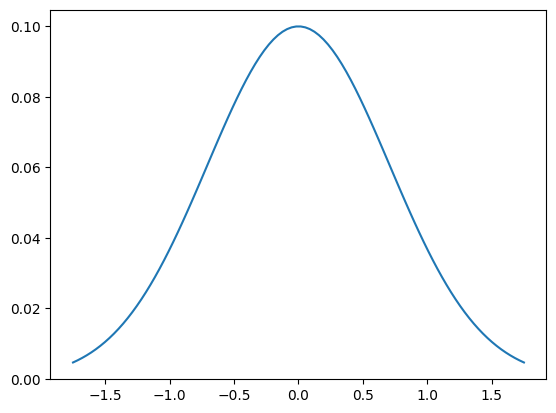

In [55]:
r_dish=np.linspace(-1.75, 1.75, 100)
Edish=0.1*np.exp(-1*r_dish**2)

plt.plot(r_dish, Edish)
plt.show()

hw11 = 8.095275e+05 m


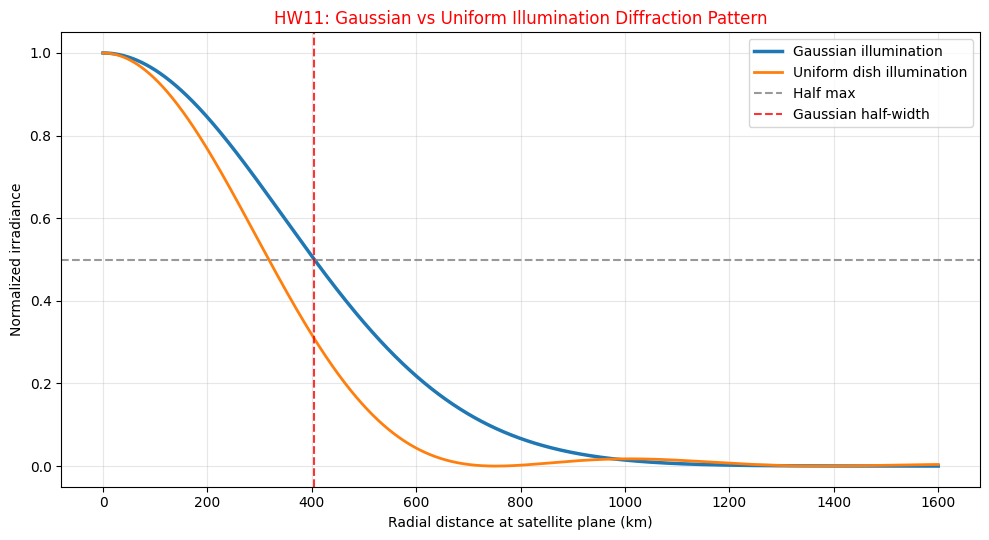

In [56]:
# HW11: Gaussian illumination vs uniform circular dish at z = 36,000 km

# Parameters
f_freq = 5e9
c = 3e8
wavelength = c / f_freq
z = 36000 * 1000
R = 1.75  # dish radius (m)

# Observation radius in the satellite plane
r11 = np.linspace(0, 1.6e6, 30001)  # m
f_r11 = r11 / (wavelength * z)       # cycles/m

# Uniform circular dish field amplitude (Airy pattern): J1(u)/u
u = 2 * np.pi * R * f_r11
E_uniform = np.ones_like(r11)
mask_u = u > 1e-10
E_uniform[mask_u] = np.abs(special.j1(u[mask_u]) / u[mask_u])
E_uniform[0] = 0.5
I_uniform = E_uniform**2
I_uniform_norm = I_uniform / np.max(I_uniform)

# Gaussian illumination in aperture plane: E(r') = 0.1 * exp(-(r')^2)
# Fraunhofer field (ignoring clipping) is also Gaussian in spatial frequency.
# Constants do not affect normalized irradiance.
E_gauss = np.exp(-(np.pi * f_r11)**2)
I_gauss = E_gauss**2
I_gauss_norm = I_gauss / np.max(I_gauss)

# FWHM of Gaussian irradiance pattern
half_val = 0.5
idx_half_g = np.where(I_gauss_norm <= half_val)[0][0]

# Interpolate for better half-maximum crossing accuracy
r_left = r11[idx_half_g - 1]
r_right = r11[idx_half_g]
I_left = I_gauss_norm[idx_half_g - 1]
I_right = I_gauss_norm[idx_half_g]
r_half_g = np.interp(half_val, [I_right, I_left], [r_right, r_left])

hw11 = 2 * r_half_g

print(f"hw11 = {hw11:.6e} m")

# Plot normalized linear diffraction patterns
plt.figure(figsize=(10, 5.5))
plt.plot(r11 / 1000, I_gauss_norm, linewidth=2.5, label='Gaussian illumination')
plt.plot(r11 / 1000, I_uniform_norm, linewidth=2.0, label='Uniform dish illumination')
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.8, label='Half max')
plt.axvline(r_half_g / 1000, color='r', linestyle='--', alpha=0.8, label='Gaussian half-width')
plt.xlabel('Radial distance at satellite plane (km)')
plt.ylabel('Normalized irradiance')
plt.title('HW11: Gaussian vs Uniform Illumination Diffraction Pattern', color='red')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
